In [1]:
from fit_dyn_f import load_data, generate_outlines, generate_inner_outlines, generate_dyn_field_old, preprocess_bfs, DynFieldModel
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from tqdm import tqdm

In [22]:
# Constants and data
data_path = '../run/data-dyn_f-fit/results.h5'

# Model parameters
dyn_sigma = 10.2
scale_factor = 0.5902834534645081

In [23]:
# Load data
dset_nuc, dset_cell, dset_AC = load_data(data_path)
nuc_outline = generate_outlines(dset_nuc)
nuc_inner_outline = generate_inner_outlines(dset_nuc)
cell_inner_outline = generate_inner_outlines(dset_cell)

samples = dset_nuc.shape[0]

# Pytorch device
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [24]:
# Generate old dyn_f values
dyn_f_old_protr = []
dyn_f_old_retr = []
for i in tqdm(range(samples)):
    dyn_f_old_protr.append(
        generate_dyn_field_old(nuc_outline[i], cell_inner_outline[i], dset_AC[i])
    )
    dyn_f_old_retr.append(
        generate_dyn_field_old(
            nuc_inner_outline[i], cell_inner_outline[i], dset_AC[i], True
        )
    )

dyn_f_old_protr = np.array(dyn_f_old_protr)
dyn_f_old_retr = np.array(dyn_f_old_retr)

dyn_f_old_protr_torch = torch.tensor(dyn_f_old_protr, dtype=torch.float32).to(device)
dyn_f_old_retr_torch = torch.tensor(dyn_f_old_retr, dtype=torch.float32).to(device)

100%|██████████| 11/11 [00:21<00:00,  1.93s/it]


In [25]:
# Generate new values
dyn_f_pre = []
for _ in tqdm(range(samples)):
    dyn_f_pre.append(
        preprocess_bfs(
            dset_cell[i], cell_inner_outline[i], nuc_inner_outline[i], dset_AC[i]
        )
    )

dyn_f_pre = np.array(dyn_f_pre)
dyn_f_pre_torch = torch.tensor(dyn_f_pre, dtype=torch.float32).to(device)

100%|██████████| 11/11 [00:01<00:00,  8.25it/s]


In [26]:
with torch.no_grad():
  new_model = DynFieldModel().to(device)

  new_model.dyn_sigma = nn.Parameter(torch.tensor(dyn_sigma, device=device))
  new_model.scale_factor = nn.Parameter(torch.tensor(scale_factor, device=device))

  dyn_f_new_protr = new_model(dyn_f_pre_torch, "protrude").cpu().numpy()
  dyn_f_new_retr = new_model(dyn_f_pre_torch, "retract").cpu().numpy()

  dyn_f_new_protr[~nuc_inner_outline] = 0
  dyn_f_new_retr[~nuc_inner_outline] = 0

In [27]:
def plot_heatmap(data, ax, x_lim, y_lim, fig):
  im = ax.imshow(data)
  ax.set_xlim(x_lim[0], x_lim[1])
  ax.set_ylim(y_lim[0], y_lim[1])
  fig.colorbar(im, ax=ax)

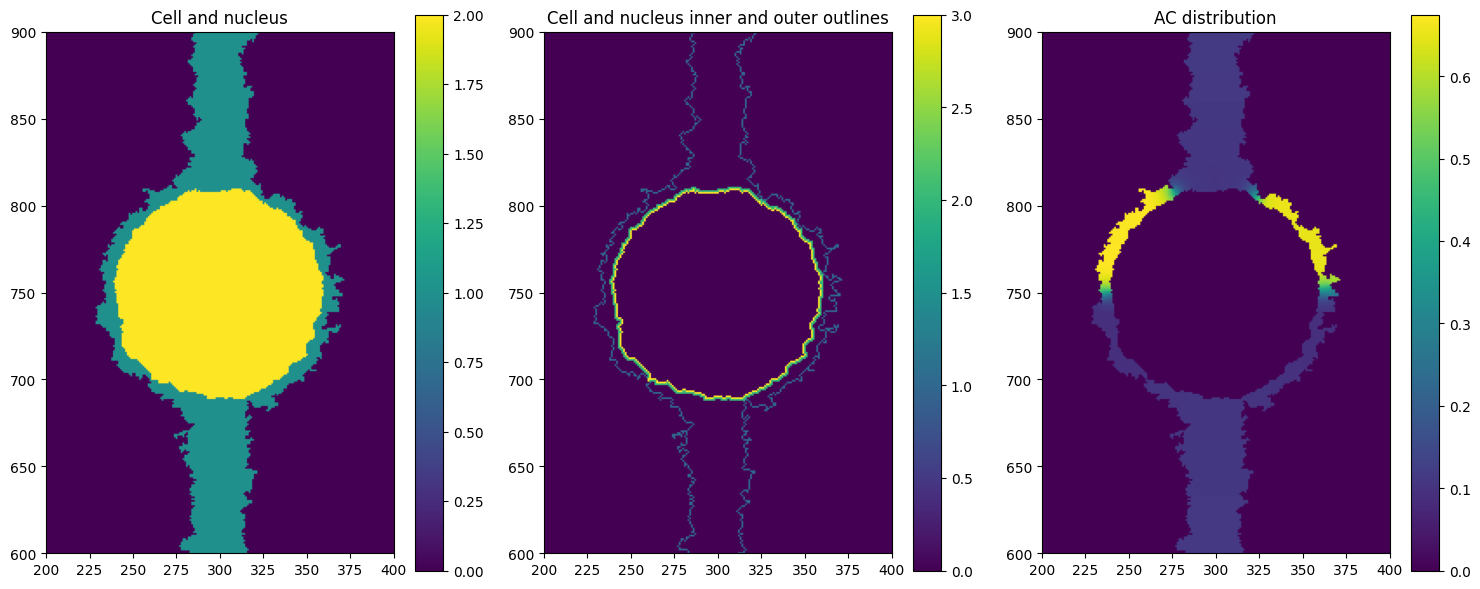

In [28]:
fig, axs = plt.subplots(1, 3, figsize=(15, 6))

index = 5
x_lim = (200, 400)
y_lim = (600, 900)

plot_heatmap(dset_cell[index] + 1 * dset_nuc[index], axs[0], x_lim, y_lim, fig)
plot_heatmap(cell_inner_outline[index] + 2 * nuc_outline[index] + 3 * nuc_inner_outline[index], axs[1], x_lim, y_lim, fig)
plot_heatmap(dset_AC[index], axs[2], x_lim, y_lim, fig)

axs[0].set_title("Cell and nucleus")
axs[1].set_title("Cell and nucleus inner and outer outlines")
axs[2].set_title("AC distribution")

plt.tight_layout()
plt.show()

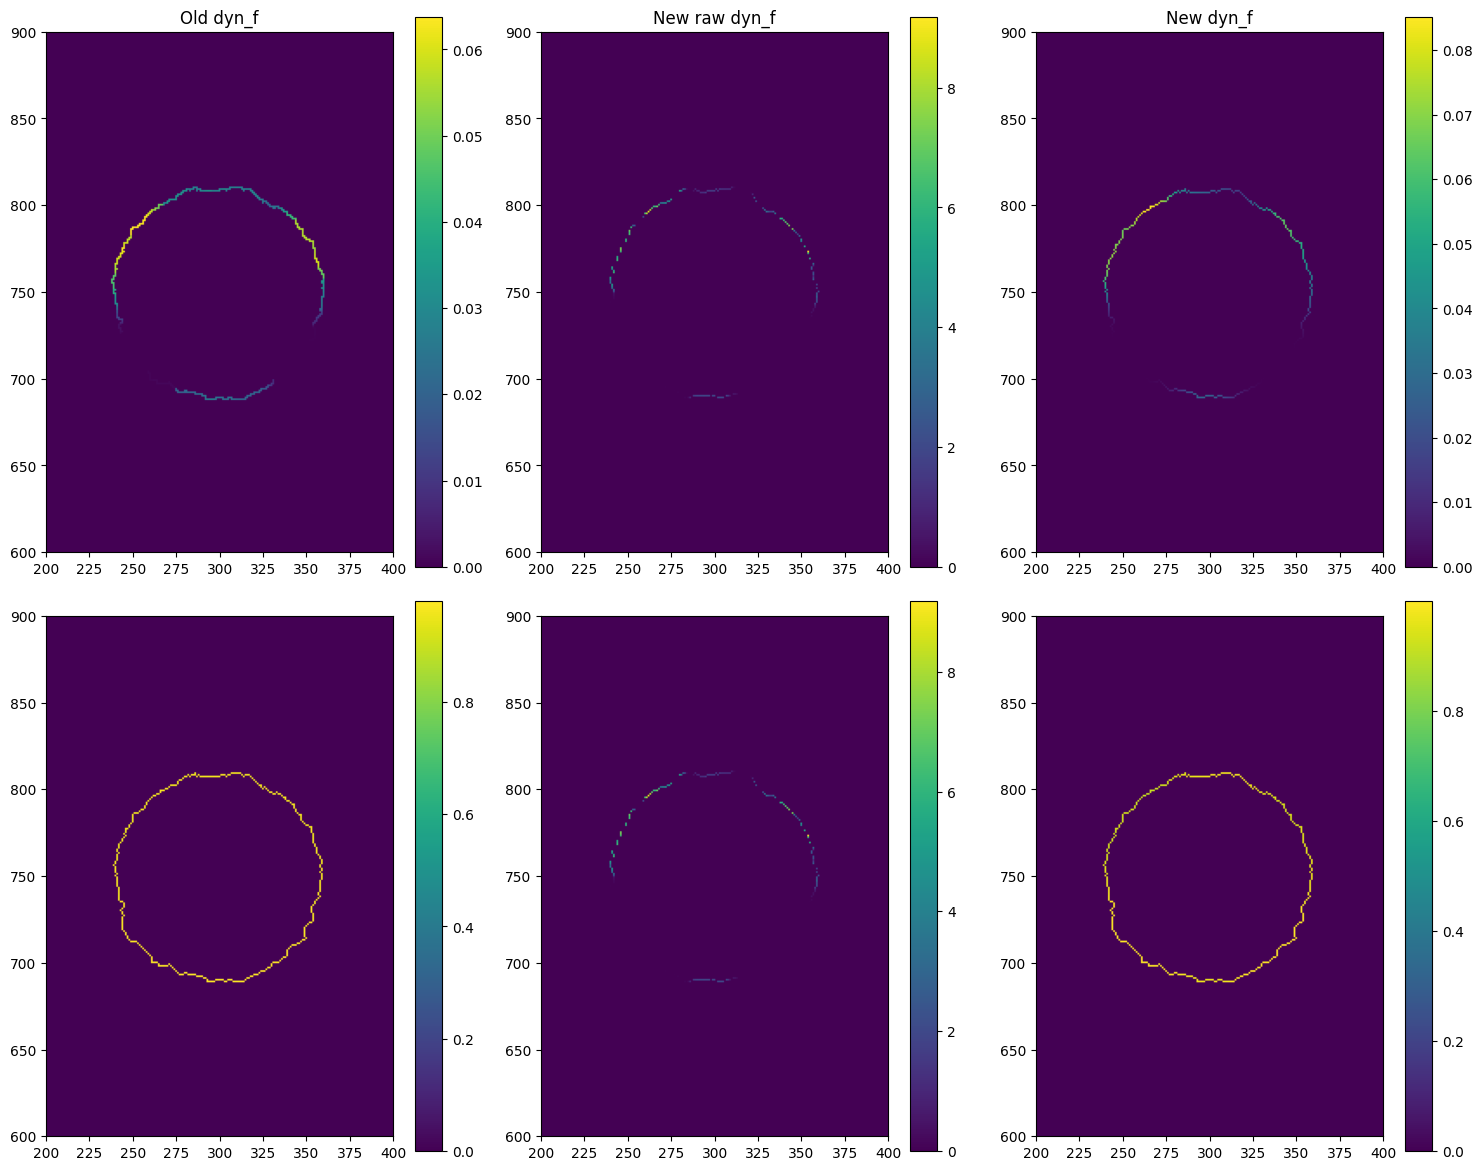

In [29]:
fig, axs = plt.subplots(2, 3, figsize=(15, 12))

index = 5
x_lim = (200, 400)
y_lim = (600, 900)

plot_heatmap(dyn_f_old_protr[index], axs[0, 0], x_lim, y_lim, fig)
plot_heatmap(dyn_f_pre[index], axs[0, 1], x_lim, y_lim, fig)
plot_heatmap(dyn_f_new_protr[index], axs[0, 2], x_lim, y_lim, fig)

plot_heatmap(dyn_f_old_retr[index], axs[1, 0], x_lim, y_lim, fig)
plot_heatmap(dyn_f_pre[index], axs[1, 1], x_lim, y_lim, fig)
plot_heatmap(dyn_f_new_retr[index], axs[1, 2], x_lim, y_lim, fig)

axs[0, 0].set_title("Old dyn_f")
axs[0, 1].set_title("New raw dyn_f")
axs[0, 2].set_title("New dyn_f")

plt.tight_layout()
plt.show()

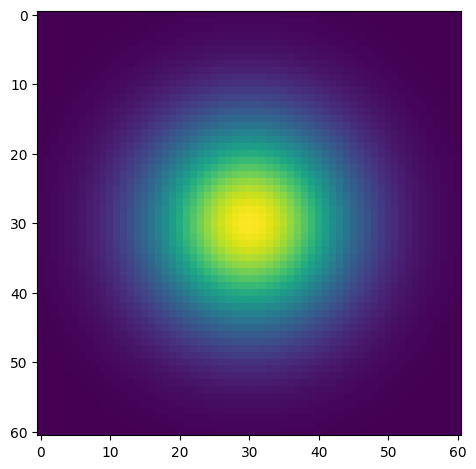

In [30]:
kernel = new_model._gaussian_kernel().detach().cpu().numpy()

fig, ax = plt.subplots(1, 1)

ax.imshow(kernel[0, 0])

plt.tight_layout()
plt.show()